# Hotel Booking Demand Data Analysis

**Group Project: Data Analysis with Python**

This notebook implements the full analysis pipeline required by the Data Science Coursework using the Hotel Booking Demand dataset. We explore booking patterns, preprocess the data, conduct statistical hypothesis testing, and perform hierarchical clustering to identify key factors influencing hotel booking cancellations.

## 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
import os
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

## 2. Data Loading

In [2]:
file_path = r"../data/raw/hotel_bookings.csv"
if not os.path.exists(file_path):
    file_path = r"c:\Users\Dell\Desktop\Python Coursework\PUSL2077-DataScience-coursework\data\raw\hotel_bookings.csv"

df = pd.read_csv(file_path)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 3. Data Cleaning & Preprocessing

### 3.1 Handling Missing Values
As per the proposal:
- Dropping `company` and `agent` columns
- Imputing `children` with zero
- Imputing `country` with its mode

In [3]:
# Drop high-nullity columns
df = df.drop(columns=['company', 'agent'])

# Impute children with 0
df['children'] = df['children'].fillna(0)

# Impute country with mode
mode_country = df['country'].mode()[0]
df['country'] = df['country'].fillna(mode_country)

print("Missing values after imputation:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values after imputation:
Series([], dtype: int64)


### 3.2 Date Engineering
Combine `arrival_date_year`, `arrival_date_month`, and `arrival_date_day_of_month` into a single datetime column.

In [5]:
month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4,
    'May': 5, 'June': 6, 'July': 7, 'August': 8,
    'September': 9, 'October': 10, 'November': 11, 'December': 12
}
df['arrival_date_month_num'] = df['arrival_date_month'].map(month_map)

df['arrival_date'] = pd.to_datetime(
    df['arrival_date_year'].astype(str) + '-' +
    df['arrival_date_month_num'].astype(str) + '-' +
    df['arrival_date_day_of_month'].astype(str)
)

df = df.drop(columns=['arrival_date_month_num'])
print("New arrival_date column sample:")
print(df['arrival_date'].head())

New arrival_date column sample:
0   2015-07-01
1   2015-07-01
2   2015-07-01
3   2015-07-01
4   2015-07-01
Name: arrival_date, dtype: datetime64[ns]


### 3.3 Feature Engineering
Create `total_nights` and `room_mismatch`.

In [6]:
# Total nights stayed
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

# Room mismatch flag
df['room_mismatch'] = (df['assigned_room_type'] != df['reserved_room_type']).astype(int)

print("New features: total_nights, room_mismatch")
df[['total_nights', 'room_mismatch']].describe()

New features: total_nights, room_mismatch


,total_nights,room_mismatch
count,119390.000000,119390.000000
mean,3.427900,0.124943
std,2.557439,0.330656
min,0.000000,0.000000
25%,2.000000,0.000000
50%,3.000000,0.000000
75%,4.000000,0.000000
max,69.000000,1.000000


### 3.4 Outlier Treatment
Remove extreme outlier in `adr` (> €5,000). Apply Winsorization at the 1st and 99th percentiles for key numerical columns.

In [7]:
# Remove extreme ADR outlier
df = df[df['adr'] <= 5000]

# Winsorize key numerical columns
numerical_cols = ['lead_time', 'adr', 'total_nights', 'booking_changes',
                  'total_of_special_requests', 'days_in_waiting_list']

for col in numerical_cols:
    lower_bound = df[col].quantile(0.01)
    upper_bound = df[col].quantile(0.99)
    df[col] = np.clip(df[col], lower_bound, upper_bound)

print(f"Dataset shape after outlier treatment: {df.shape}")

Dataset shape after outlier treatment: (119389, 33)


### 3.5 Categorical Encoding
Label encode `hotel`, `meal`, `market_segment`, `deposit_type`, `customer_type`, `reserved_room_type`.

In [8]:
categorical_to_encode = ['hotel', 'meal', 'market_segment', 'deposit_type',
                          'customer_type', 'reserved_room_type']
le_dict = {}

for col in categorical_to_encode:
    le = LabelEncoder()
    df[col + '_encoded'] = le.fit_transform(df[col])
    le_dict[col] = le

print('Encoded columns added:', [c + '_encoded' for c in categorical_to_encode])

Encoded columns added: ['hotel_encoded', 'meal_encoded', 'market_segment_encoded', 'deposit_type_encoded', 'customer_type_encoded', 'reserved_room_type_encoded']


### 3.6 Normalization
Standardize numerical features prior to clustering. Prepare a separate dataframe `df_scaled` for clustering.

In [9]:
scaler = StandardScaler()
features_to_scale = ['lead_time', 'adr', 'total_nights',
                     'booking_changes', 'total_of_special_requests']

df_scaled = df.copy()
df_scaled[features_to_scale] = scaler.fit_transform(df[features_to_scale])

# Save cleaned dataset
processed_dir = r"c:\Users\Dell\Desktop\Python Coursework\PUSL2077-DataScience-coursework\data\processed"
os.makedirs(processed_dir, exist_ok=True)
df.to_csv(os.path.join(processed_dir, 'hotel_bookings_cleaned.csv'), index=False)
print("Cleaned dataset saved to data/processed/")

Cleaned dataset saved to data/processed/


## 4. Descriptive Analysis & Visualizations

### 4.1 Overall Summary Statistics

In [10]:
print("Numerical Summary Statistics:")
display(df[numerical_cols].describe())

print("\nCancellation Rate:")
print(df['is_canceled'].value_counts(normalize=True))

Numerical Summary Statistics:


,lead_time,adr,total_nights,booking_changes,total_of_special_requests,days_in_waiting_list
count,119389.000000,119389.000000,119389.000000,119389.000000,119389.000000,119389.000000
mean,103.409753,101.459990,3.405021,0.209567,0.567850,1.606915
std,104.601174,46.903208,2.339390,0.555243,0.779259,9.760307
min,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,18.000000,69.290000,2.000000,0.000000,0.000000,0.000000
50%,69.000000,94.560000,3.000000,0.000000,0.000000,0.000000
75%,160.000000,126.000000,4.000000,0.000000,1.000000,0.000000
max,444.000000,252.000000,14.000000,3.000000,3.000000,75.000000



Cancellation Rate:
is_canceled
0    0.629589
1    0.370411
Name: proportion, dtype: float64


### 4.2 Descriptive Statistics: Cancelled vs Non-Cancelled Bookings
Side-by-side comparison of key variables across cancelled and non-cancelled bookings. This directly supports the main analytical question of the project.

In [11]:
comparison_cols = ['lead_time', 'adr', 'total_nights',
                   'total_of_special_requests', 'booking_changes',
                   'days_in_waiting_list']

cancelled_compare = df.groupby('is_canceled')[comparison_cols].agg(['mean', 'median', 'std']).T
cancelled_compare.columns = ['Not Cancelled (0)', 'Cancelled (1)']

print("Descriptive Statistics — Cancelled vs Non-Cancelled Bookings:")
display(cancelled_compare)

Descriptive Statistics — Cancelled vs Non-Cancelled Bookings:


Not Cancelled (0)  Cancelled (1)
lead_time                 mean            79.855480     143.445040
                          median          45.000000     113.000000
                          std             90.542924     114.274903
adr                       mean            99.648698     104.538650
                          median          92.500000      96.200000
                          std             47.916967      44.961325
total_nights              mean             3.379640       3.448160
                          median           3.000000       3.000000
                          std              2.390319       2.249553
total_of_special_requests mean             0.709004       0.327929
                          median           1.000000       0.000000
                          std              0.816187       0.644736
booking_changes           mean             0.278078       0.093119
                          median           0.000000       0.000000
                          std              0.621438       0.392899
days_in_waiting_list      mean             1.041388       2.568143
                          median           0.000000       0.000000
                          std              8.187047      11.907611

### 4.3 Visualizations

#### Chart 1 — Cancellation Rates by Market Segment and Hotel Type

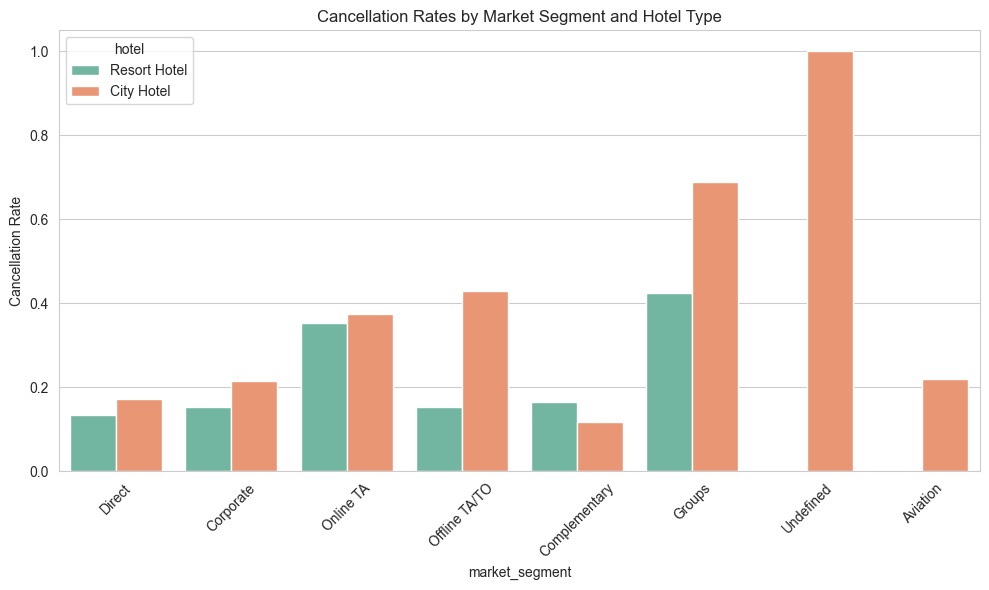

In [12]:
sns.set_palette('Set2')
sns.set_style('whitegrid')

plt.figure(figsize=(10, 6))
sns.barplot(x='market_segment', y='is_canceled', hue='hotel', data=df, errorbar=None)
plt.title("Cancellation Rates by Market Segment and Hotel Type")
plt.xticks(rotation=45)
plt.ylabel("Cancellation Rate")
plt.tight_layout()
plt.show()

#### Chart 2 — Average Daily Rate (ADR) by Month and Hotel Type
Splitting by hotel type reveals that Resort Hotel ADR peaks sharply in summer, while City Hotel rates remain relatively stable year-round.

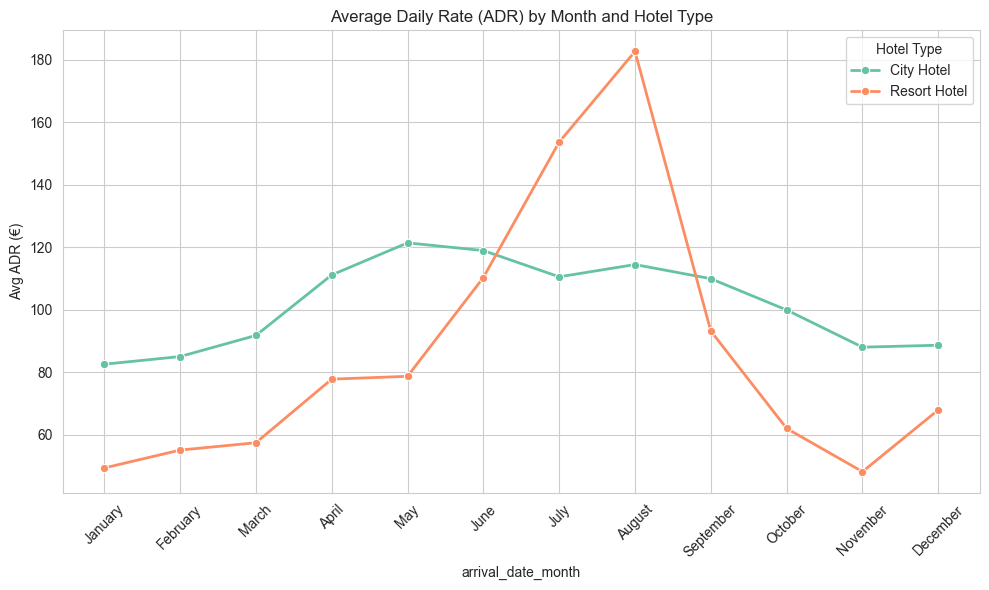

In [13]:
monthly_stats = df.groupby(['arrival_date_month', 'hotel'])['adr'].mean().reset_index()
monthly_stats['arrival_date_month'] = pd.Categorical(
    monthly_stats['arrival_date_month'],
    categories=list(month_map.keys()), ordered=True
)
monthly_stats = monthly_stats.sort_values('arrival_date_month')

plt.figure(figsize=(10, 6))
sns.lineplot(x='arrival_date_month', y='adr', hue='hotel',
             data=monthly_stats, marker='o', linewidth=2)
plt.title("Average Daily Rate (ADR) by Month and Hotel Type")
plt.xticks(rotation=45)
plt.ylabel("Avg ADR (\u20ac)")
plt.legend(title='Hotel Type')
plt.tight_layout()
plt.show()

#### Chart 3 — Lead Time by Cancellation Status

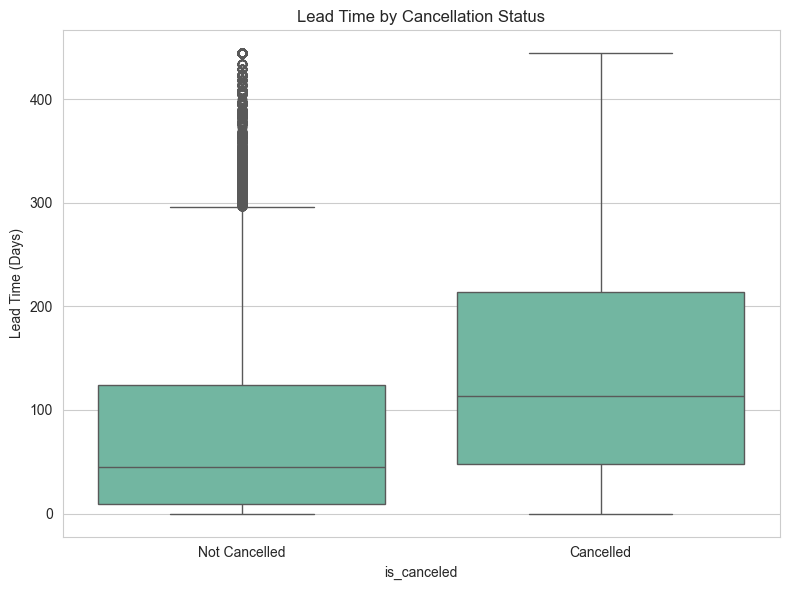

In [14]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='is_canceled', y='lead_time', data=df)
plt.title("Lead Time by Cancellation Status")
plt.xticks([0, 1], ['Not Cancelled', 'Cancelled'])
plt.ylabel("Lead Time (Days)")
plt.tight_layout()
plt.show()

#### Chart 4 — Distribution of Deposit Types

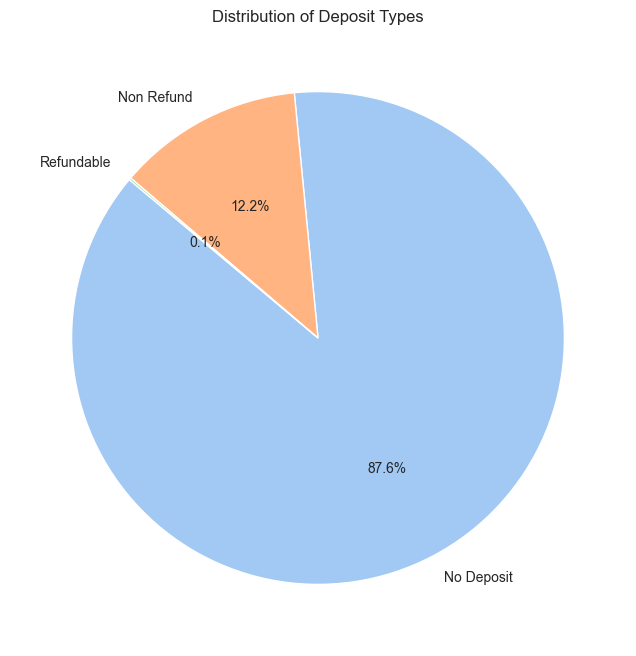

In [15]:
deposit_counts = df['deposit_type'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(deposit_counts, labels=deposit_counts.index, autopct='%1.1f%%',
        startangle=140, colors=sns.color_palette('pastel'))
plt.title("Distribution of Deposit Types")
plt.show()

#### Chart 5 — Top 10 Guest Countries of Origin

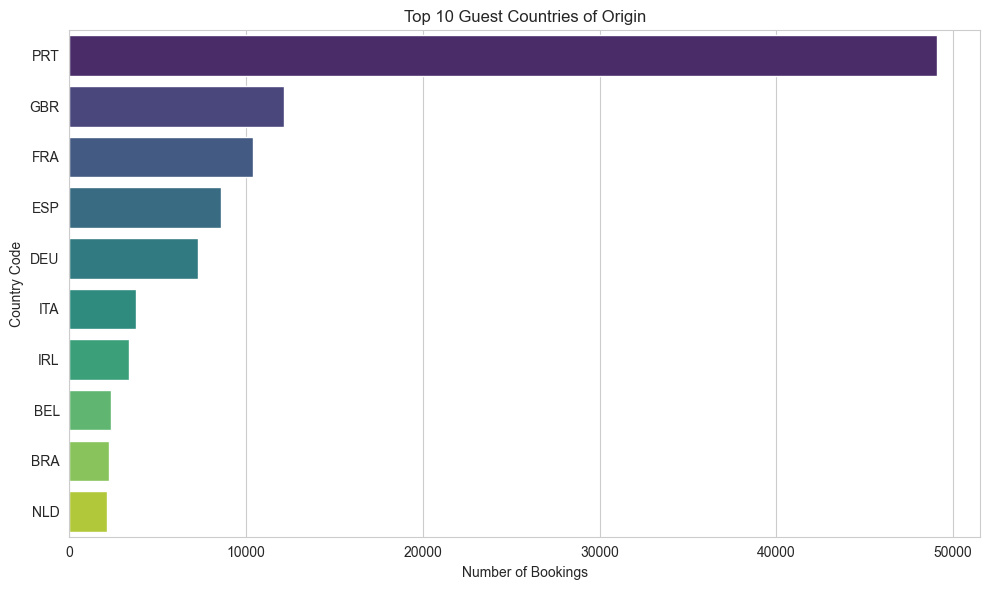

In [16]:
top_countries = df['country'].value_counts().nlargest(10).index
plt.figure(figsize=(10, 6))
sns.countplot(y='country', data=df[df['country'].isin(top_countries)],
              order=top_countries, palette='viridis')
plt.title("Top 10 Guest Countries of Origin")
plt.xlabel("Number of Bookings")
plt.ylabel("Country Code")
plt.tight_layout()
plt.show()

#### Chart 6 — Correlation Heatmap of Key Variables

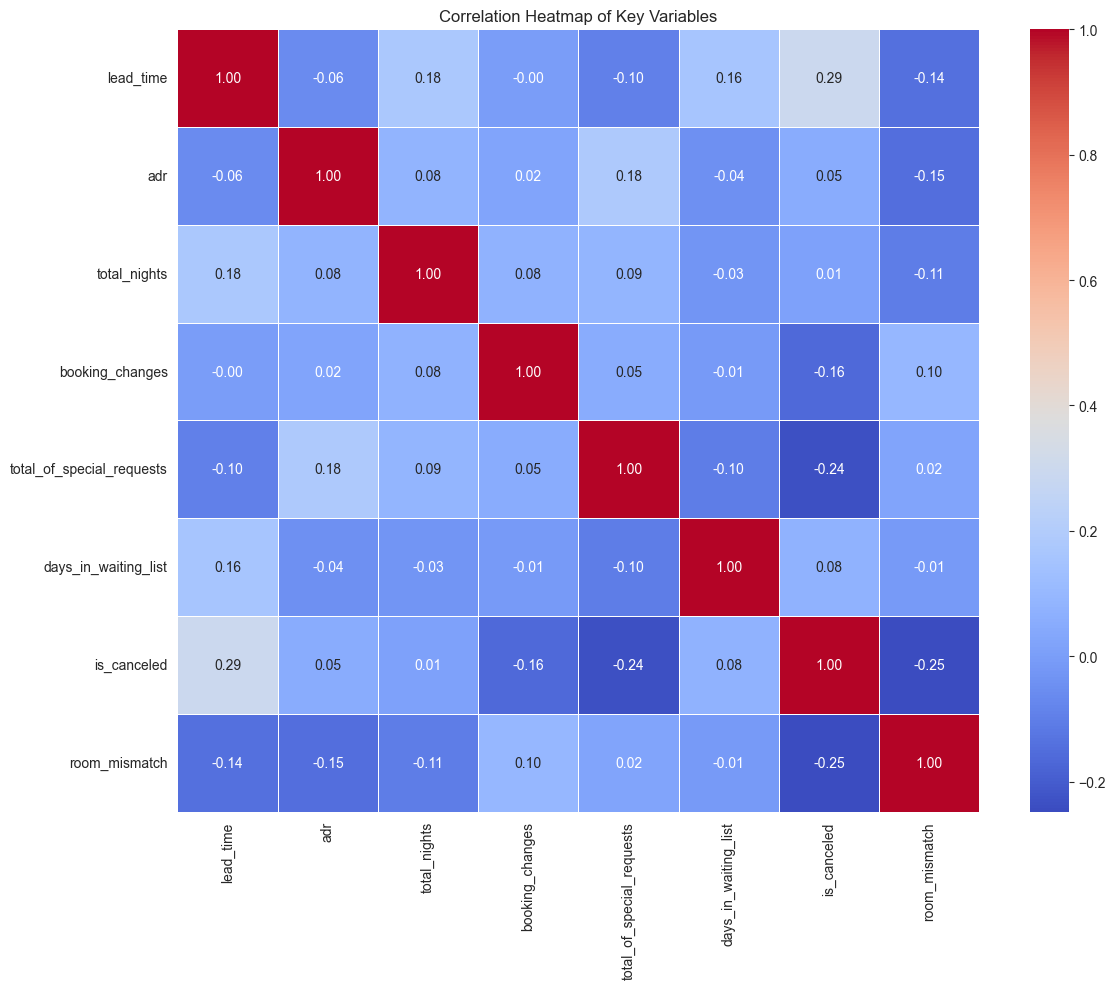

In [17]:
plt.figure(figsize=(12, 10))
corr_cols = numerical_cols + ['is_canceled', 'room_mismatch']
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm',
            fmt='.2f', linewidths=0.5)
plt.title("Correlation Heatmap of Key Variables")
plt.tight_layout()
plt.show()

#### Chart 7 — Key Variable Distributions: Cancelled vs Not Cancelled
Histogram distributions with KDE curves for the four most informative variables, split by cancellation status. Blue = Not Cancelled, Red = Cancelled.

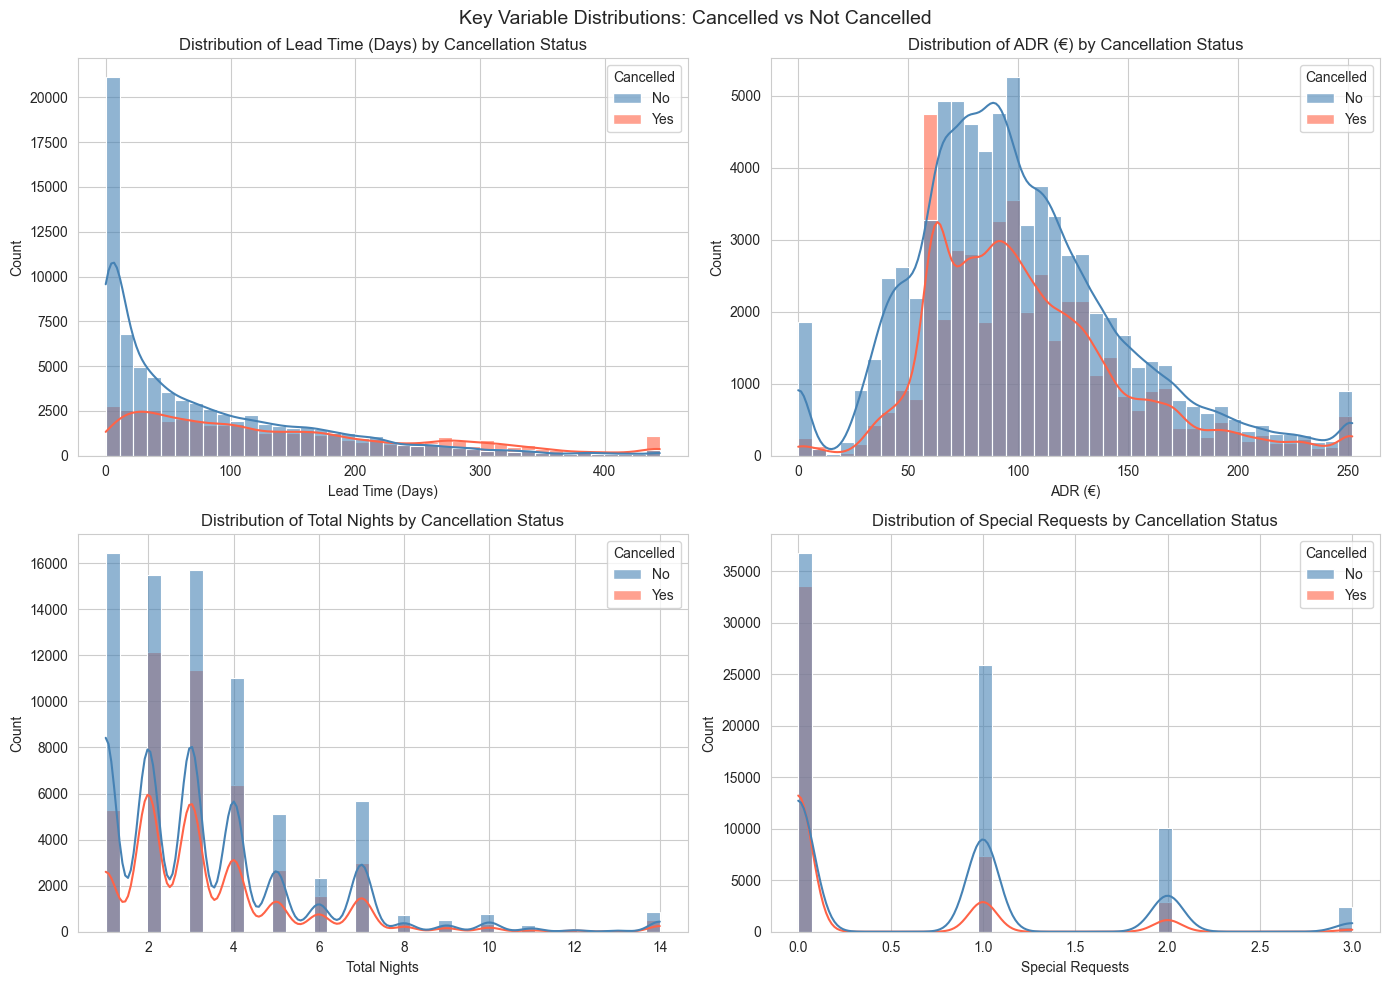

In [18]:
dist_cols   = ['lead_time', 'adr', 'total_nights', 'total_of_special_requests']
dist_labels = ['Lead Time (Days)', 'ADR (€)', 'Total Nights', 'Special Requests']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (col, label) in enumerate(zip(dist_cols, dist_labels)):
    sns.histplot(data=df, x=col, hue='is_canceled', bins=40, kde=True,
                 ax=axes[i], palette={0: 'steelblue', 1: 'tomato'}, alpha=0.6)
    axes[i].set_title(f'Distribution of {label} by Cancellation Status')
    axes[i].set_xlabel(label)
    axes[i].set_ylabel('Count')
    legend = axes[i].get_legend()
    if legend:
        legend.set_title('Cancelled')
        for t, lbl in zip(legend.texts, ['No', 'Yes']):
            t.set_text(lbl)

plt.suptitle("Key Variable Distributions: Cancelled vs Not Cancelled", fontsize=14)
plt.tight_layout()
plt.show()

## 5. Statistical Hypothesis Testing

### 5.1 Independent Samples t-test: Average Daily Rate (ADR)
- **H0:** There is no significant difference in ADR between City Hotel and Resort Hotel.
- **H1:** There is a significant difference in ADR between City Hotel and Resort Hotel.

In [19]:
city_adr   = df[df['hotel'] == 'City Hotel']['adr']
resort_adr = df[df['hotel'] == 'Resort Hotel']['adr']

t_stat_adr, p_val_adr = stats.ttest_ind(city_adr, resort_adr, equal_var=False)
print(f"ADR T-Test -> t-statistic: {t_stat_adr:.4f}, p-value: {p_val_adr:.4e}")

if p_val_adr < 0.05:
    print("Reject H0: Significant difference in ADR between City and Resort hotels.")
else:
    print("Fail to reject H0: No significant difference in ADR.")

ADR T-Test -> t-statistic: 33.6185, p-value: 2.0633e-245
Reject H0: Significant difference in ADR between City and Resort hotels.


### 5.2 Independent Samples t-test: Lead Time vs Cancellation
- **H0:** Lead time is not significantly higher for cancelled bookings.
- **H1:** Lead time is significantly higher for cancelled bookings.

In [20]:
cancelled_lead     = df[df['is_canceled'] == 1]['lead_time']
not_cancelled_lead = df[df['is_canceled'] == 0]['lead_time']

t_stat_lead, p_val_lead = stats.ttest_ind(cancelled_lead, not_cancelled_lead, equal_var=False)
one_tailed_p = p_val_lead / 2

print(f"Lead Time T-Test -> t-statistic: {t_stat_lead:.4f}, one-tailed p-value: {one_tailed_p:.4e}")

if one_tailed_p < 0.05 and t_stat_lead > 0:
    print("Reject H0: Lead time is significantly higher for cancelled bookings.")
else:
    print("Fail to reject H0.")

Lead Time T-Test -> t-statistic: 100.0005, one-tailed p-value: 0.0000e+00
Reject H0: Lead time is significantly higher for cancelled bookings.


### 5.3 Chi-Square Test: Cancellation Rates Across Market Segments
- **H0:** Cancellation status is independent of market segment.
- **H1:** Cancellation status is dependent on market segment.

In [21]:
contingency_table = pd.crosstab(df['market_segment'], df['is_canceled'])
chi2, p_val_chi2, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Chi-Square Test -> Chi2: {chi2:.4f}, p-value: {p_val_chi2:.4e}, dof: {dof}")
if p_val_chi2 < 0.05:
    print("Reject H0: Cancellation rates differ significantly across market segments.")
else:
    print("Fail to reject H0.")

Chi-Square Test -> Chi2: 8497.4243, p-value: 0.0000e+00, dof: 7
Reject H0: Cancellation rates differ significantly across market segments.


## 6. Hierarchical Clustering

We apply Agglomerative Hierarchical Clustering using Ward Linkage on a random sample of 5,000 rows (hierarchical clustering is $O(N^2)$–$O(N^3)$). Clustering features: lead time, ADR, total nights, booking changes, and total special requests.

### 6.1 Dendrogram

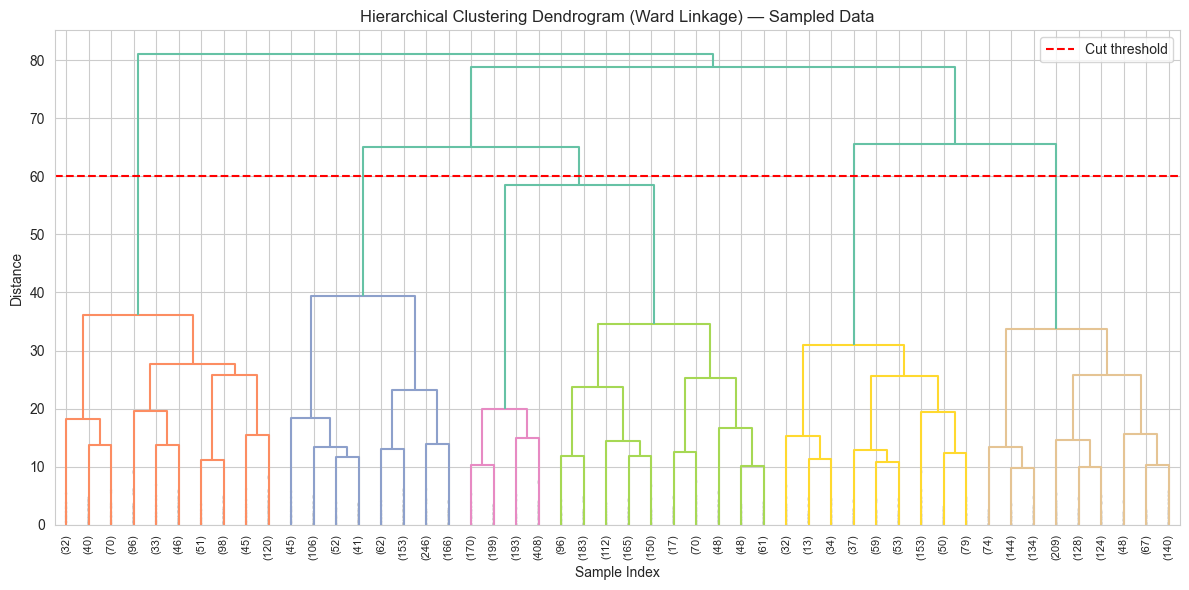

In [22]:
sample_size = min(5000, len(df_scaled))
np.random.seed(42)
df_sample = df_scaled.sample(n=sample_size, random_state=42)
cluster_features = df_sample[features_to_scale]

Z = linkage(cluster_features, method='ward')

plt.figure(figsize=(12, 6))
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage) — Sampled Data")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
dendrogram(Z, truncate_mode='lastp', p=50, leaf_rotation=90.,
           leaf_font_size=8., show_contracted=True)
plt.axhline(y=60, color='r', linestyle='--', label='Cut threshold')
plt.legend()
plt.tight_layout()
plt.show()

### 6.2 Cluster Profiles
Apply Agglomerative Clustering to form 4 clusters and profile each cluster against key features and cancellation rate.

In [23]:
cluster_model = AgglomerativeClustering(n_clusters=4, linkage='ward')
df_sample['Cluster'] = cluster_model.fit_predict(cluster_features)

# Reverse scaling to get interpretable feature values
profile_df = df_sample.copy()
profile_df[features_to_scale] = scaler.inverse_transform(profile_df[features_to_scale])

cluster_profiles = profile_df.groupby('Cluster').agg(
    lead_time=('lead_time', 'mean'),
    adr=('adr', 'mean'),
    total_nights=('total_nights', 'mean'),
    booking_changes=('booking_changes', 'mean'),
    special_requests=('total_of_special_requests', 'mean'),
    cancellation_rate=('is_canceled', 'mean'),
    count=('is_canceled', 'count')
).reset_index()

print("Cluster Profiles:")
display(cluster_profiles)
print("\nThe cluster with the highest cancellation_rate is the highest-risk guest segment.")

Cluster Profiles:


,Cluster,lead_time,adr,total_nights,booking_changes,special_requests,cancellation_rate,count
0,0,46.651738,107.952375,2.710498,0.041204,0.639197,0.338947,2791
1,1,101.294770,89.461537,3.461173,1.374010,0.702060,0.155309,631
2,2,234.614232,90.843839,2.723783,0.000000,0.246255,0.638577,1068
3,3,145.792157,94.997059,8.041176,0.047059,0.684314,0.350980,510



The cluster with the highest cancellation_rate is the highest-risk guest segment.


### 6.3 Cluster Cancellation Rate — Bar Chart
Compares the cancellation rate across all four clusters to clearly identify the highest-risk segment.

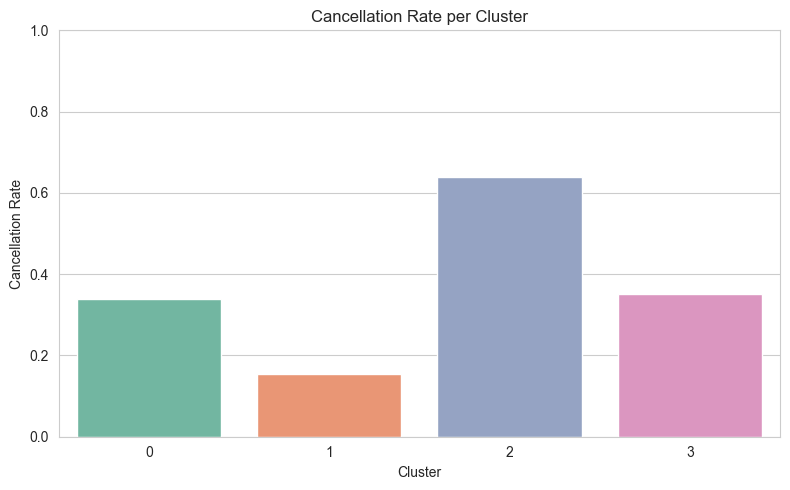

In [24]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Cluster', y='is_canceled', data=profile_df, errorbar=None, palette='Set2')
plt.title("Cancellation Rate per Cluster")
plt.ylabel("Cancellation Rate")
plt.xlabel("Cluster")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### 6.4 Cluster Separation — Scatter Plot (Lead Time vs ADR)
Shows how the four clusters separate in the lead time / ADR feature space. Each colour represents a different cluster.

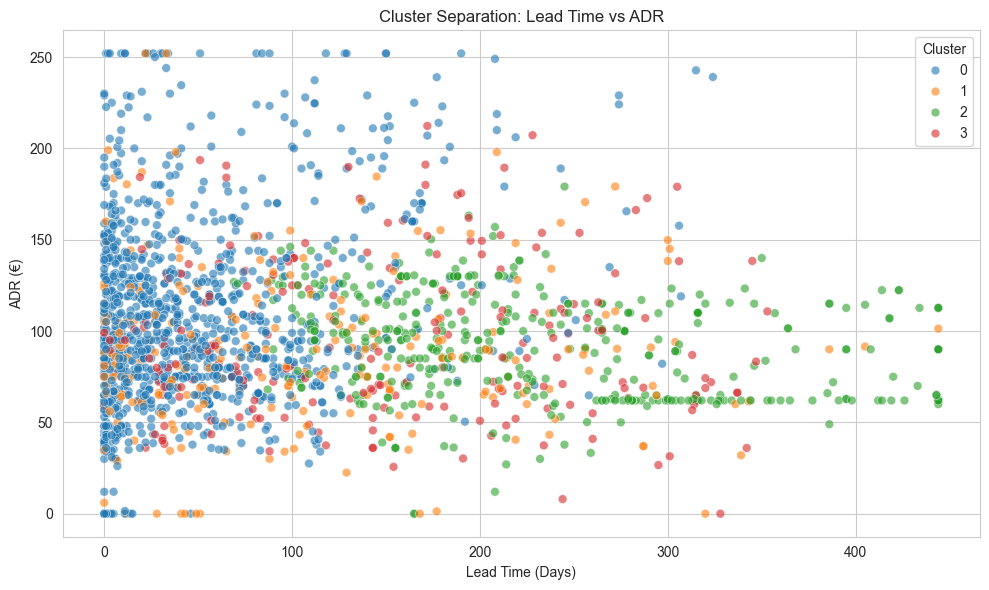

In [25]:
scatter_sample = profile_df.sample(min(2000, len(profile_df)), random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(x='lead_time', y='adr', hue='Cluster',
                data=scatter_sample, palette='tab10', alpha=0.6, s=40)
plt.title("Cluster Separation: Lead Time vs ADR")
plt.xlabel("Lead Time (Days)")
plt.ylabel("ADR (€)")
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

## 7. Conclusion & Recommendations

### Conclusion
- **Lead Time:** Bookings placed further in advance have significantly higher cancellation rates (confirmed by t-test, p ≈ 0).
- **Market Segment:** Cancellation rates differ significantly across market segments (χ² test, p ≈ 0). Online Travel Agents (OTAs) show higher cancellation tendencies than Direct bookings.
- **ADR Difference:** There is a statistically significant difference in ADR between City and Resort hotels (t-test, p ≈ 0). Resort ADR peaks sharply in summer months.
- **Special Requests:** Guests with more special requests cancel significantly less — visible in both the descriptive stats comparison table and the histogram distributions.
- **Hierarchical Clustering:** The high-risk cluster is characterised by long lead times and zero special requests. This segment has the highest cancellation rate across all clusters.

### Business Actionable Recommendations
1. **Deposit Policies:** Apply stricter or non-refundable deposit requirements for bookings made more than 60 days in advance.
2. **Special Requests:** Proactively engage guests prior to arrival to encourage special requests — this correlates strongly with lower cancellation rates.
3. **Targeted Pricing:** Offer exclusive pricing for direct bookings vs OTA bookings to reduce dependency on high-cancellation channels.
4. **Seasonal Strategy:** Resort hotels should capitalise on summer ADR peaks with early-bird offers to lock in bookings and reduce last-minute cancellations.